#CodeAlpha Internship
##Task 3:Handwritten Character Recognition
###Name: Kartik Dixit
### Objective

The objective of this project is to build a Deep Learning model that recognizes handwritten digits (0–9) using the MNIST dataset. The model is trained on thousands of handwritten images and learns to classify digits with high accuracy using TensorFlow and Keras.

##Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

##Load Dataset

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


##Explore Dataset

In [3]:
print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)
print("Testing Images  :", X_test.shape)
print("Testing Labels  :", y_test.shape)

Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images  : (10000, 28, 28)
Testing Labels  : (10000,)


##Display Sample Images

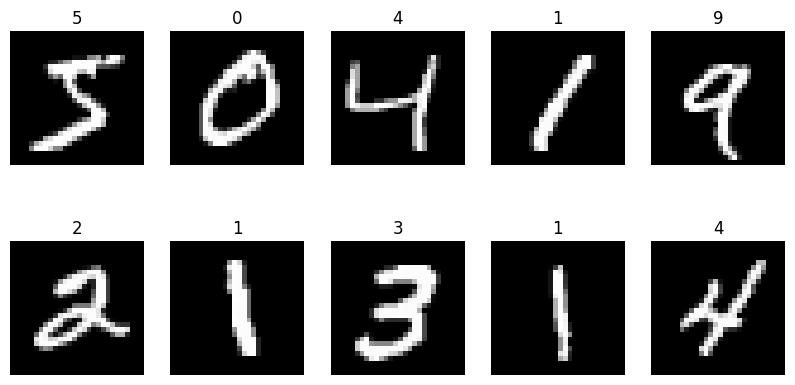

In [4]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.show()

##Data Preprocessing

In [5]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Data Preprocessing Completed!")

Data Preprocessing Completed!


##Build the Neural Network Model

In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

##Compile the Model

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

##Train the Model

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9296 - loss: 0.2421 - val_accuracy: 0.9614 - val_loss: 0.1236
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9682 - loss: 0.1020 - val_accuracy: 0.9703 - val_loss: 0.0996
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9787 - loss: 0.0702 - val_accuracy: 0.9707 - val_loss: 0.0925
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9832 - loss: 0.0539 - val_accuracy: 0.9762 - val_loss: 0.0841
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9858 - loss: 0.0429 - val_accuracy: 0.9780 - val_loss: 0.0753
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9890 - loss: 0.0336 - val_accuracy: 0.9760 - val_loss: 0.0813
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9902 - loss: 0.0302 - val_accuracy: 0.9758 - val_loss: 0.0904
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9921 - loss: 0

##Evaluate the Model

In [9]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9770 - loss: 0.0981
Test Loss: 0.09805562347173691
Test Accuracy: 0.9769999980926514


##Make Predictions

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted Digit: 7
Actual Digit: 7


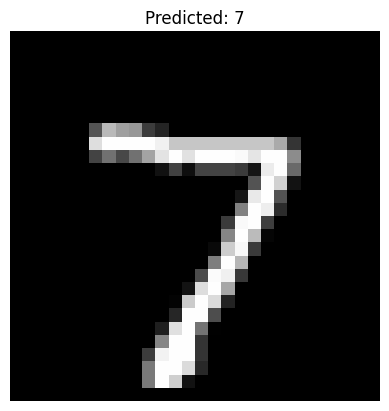

In [10]:
predictions = model.predict(X_test)

predicted_digit = np.argmax(predictions[0])

print("Predicted Digit:", predicted_digit)
print("Actual Digit:", y_test[0])

plt.imshow(X_test[0], cmap='gray')
plt.title(f"Predicted: {predicted_digit}")
plt.axis("off")
plt.show()

##Save the Model

In [11]:
model.save("handwritten_character_recognition.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


##Training Accuracy & Loss Graph

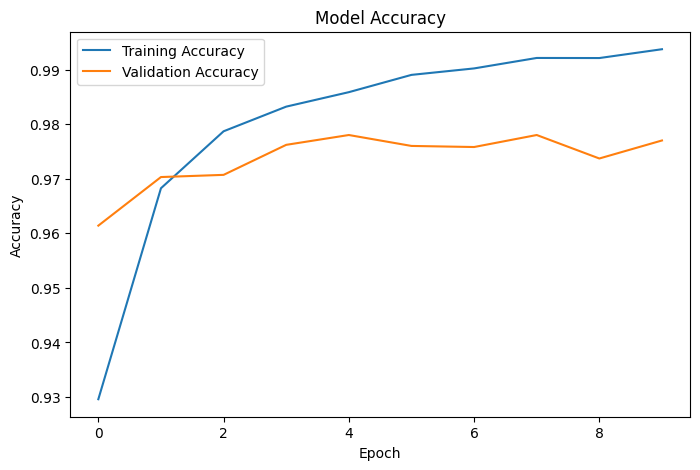

In [12]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

###Loss


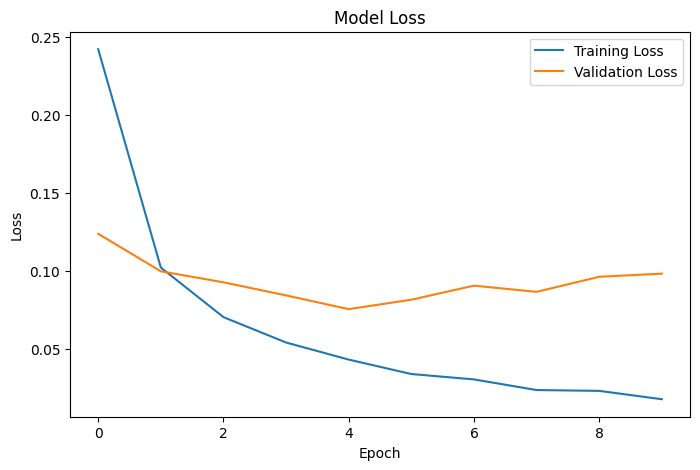

In [13]:

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

#Conclusion
# Conclusion

A Handwritten Character Recognition model was successfully developed using the MNIST dataset and a Deep Learning Neural Network.

The model was trained and evaluated using TensorFlow/Keras. After preprocessing the data and training for multiple epochs, the model achieved high accuracy in recognizing handwritten digits from 0 to 9.

This project demonstrates the effectiveness of deep learning in image classification tasks and can be extended to recognize handwritten alphabets and characters.

##Save Training History

In [14]:
import pandas as pd

history_df = pd.DataFrame(history.history)
history_df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.929600,0.242113,0.9614,0.123632
1,0.968250,0.101980,0.9703,0.099571
2,0.978683,0.070159,0.9707,0.092499
3,0.983200,0.053857,0.9762,0.084091
4,0.985850,0.042902,0.9780,0.075285


##Download the Model

In [15]:
from google.colab import files

files.download("handwritten_character_recognition.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>